In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
!pip install pyiqa

In [12]:
!git clone https://github.com/IDKiro/DehazeFormer.git

Cloning into 'DehazeFormer'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 94 (delta 17), reused 11 (delta 11), pack-reused 70 (from 2)
Receiving objects: 100% (94/94), 768.88 KiB | 3.29 MiB/s, done.
Resolving deltas: 100% (43/43), done.


In [13]:
%cd DehazeFormer

/content/DehazeFormer/DehazeFormer


In [14]:
!pip install timm einops
!pip install pytorch_msssim

In [15]:
!ls /content/drive/MyDrive/DehazeFormer
# Remove old symlink if any
!rm -rf saved_models
!rm -rf data

# ✅ Create new symlinks using the correct path (from MyDrive)
!ln -s "/content/drive/MyDrive/DehazeFormer/saved_models" saved_models
!ln -s "/content/drive/MyDrive/DehazeFormer/data" data

# ✅ Confirm the indoor folder exists
!ls saved_models/outdoor
!ls saved_models/outdoor
!pip install image-quality
!pip install opencv-contrib-python
!pip install pyiqa

data  saved_models
dehazeformer-b.pth  dehazeformer-m.pth	dehazeformer-s.pth  dehazeformer-t.pth
dehazeformer-b.pth  dehazeformer-m.pth	dehazeformer-s.pth  dehazeformer-t.pth


Saving YSM_Google_665.png to YSM_Google_665.png
Uploaded file: YSM_Google_665.png
Using uploaded file: YSM_Google_665.png


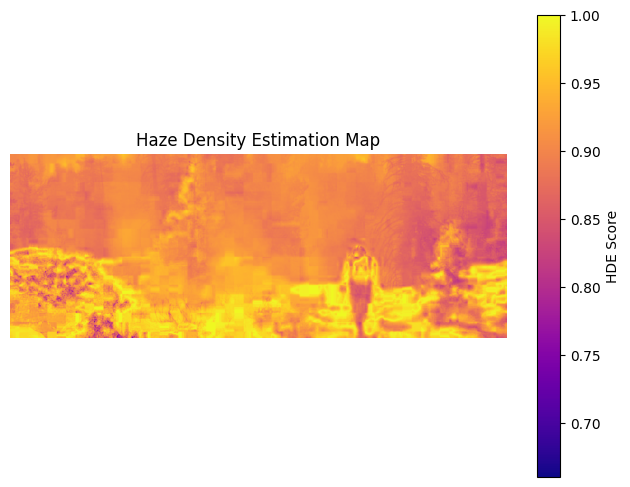

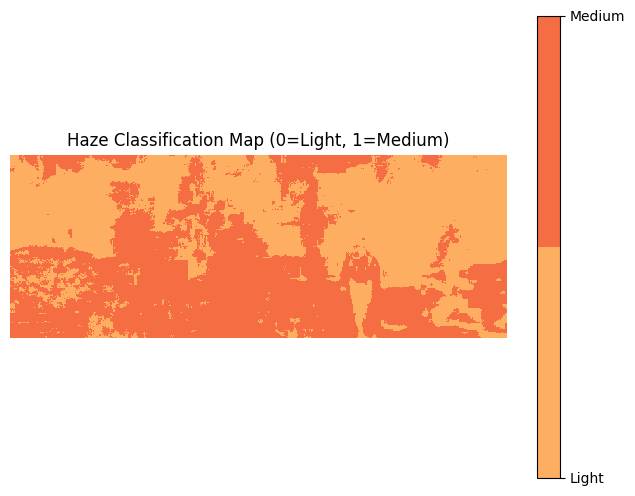

Percentile threshold:
  Light < 0.906
  Medium ≥ 0.906
Saved enhanced image as: processed_YSM_Google_665.png


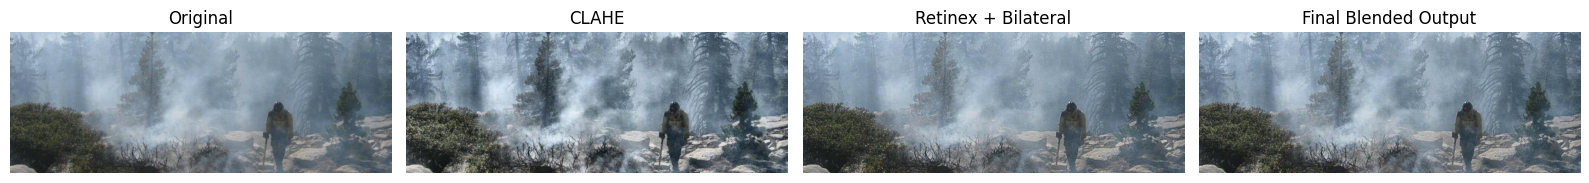

In [17]:
import os
from google.colab import files
from PIL import Image

# Upload a single image interactively
uploaded = files.upload()

# Get uploaded filename
if uploaded:
    filename = list(uploaded.keys())[0]
    print(f"Uploaded file: {filename}")

    # Open and display the image
    img = Image.open(filename).convert('RGB')
    img.show()
else:
    print("No file uploaded!")
#Pre Processing Code Final
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
from matplotlib.colors import ListedColormap

CLAHE_CLIP = 1.0
FEATHER_SIGMA = 21
PATCH_SIZE = 6
DETAIL_BOOST = 1.5

def get_dark_channel(img, r=7):
    min_channel = np.min(img, axis=2)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2*r+1, 2*r+1))
    return cv2.erode(min_channel, kernel)

def get_sharpness(gray_img):
    laplacian = cv2.Laplacian(gray_img, cv2.CV_32F)
    return np.var(laplacian)

def compute_hde_fast(img_patch, hsv_patch, gray_patch, sigma_I, kappa=0.04):
    img_patch = img_patch.astype(np.float32)
    I_min = get_dark_channel(img_patch, r=7)
    I_max_min = np.max(img_patch, axis=2) - np.min(img_patch, axis=2)
    A = np.percentile(hsv_patch[:, :, 2], 99.9) + 1e-6
    B = (I_max_min.mean() * sigma_I) / (kappa + 1e-6)
    sqrt_arg = B * (B - A + I_min + 1e-6)
    sqrt_arg = np.clip(sqrt_arg, a_min=0, a_max=None)
    sqrt_term = np.sqrt(sqrt_arg)
    t_hat = 1 - (1 / A) * (I_min + B - sqrt_term)
    return np.mean(1 - np.nan_to_num(t_hat))

def compute_hde_map(image, patch_size=32):
    h, w, _ = image.shape
    hde_map = np.zeros((h, w), dtype=np.float32)
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    sigma_I = get_sharpness(gray)

    for i in range(0, h, patch_size):
        for j in range(0, w, patch_size):
            patch = image[i:i+patch_size, j:j+patch_size]
            if patch.shape[:2] == (patch_size, patch_size):
                hde = compute_hde_fast(
                    patch,
                    hsv[i:i+patch_size, j:j+patch_size],
                    gray[i:i+patch_size, j:j+patch_size],
                    sigma_I
                )
                hde_map[i:i+patch_size, j:j+patch_size] = hde
    return hde_map

def apply_clahe(img_rgb, clip=1.0):
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)
    lab_eq = cv2.merge((l_clahe, a, b))
    return cv2.cvtColor(cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR), cv2.COLOR_BGR2RGB)

def apply_retinex_boost_bilateral(img_rgb, detail_amp=1.5):
    img_rgb = img_rgb.astype(np.float32)
    img_log = np.log1p(img_rgb)

    base = np.zeros_like(img_log)
    for c in range(3):
        base[:, :, c] = cv2.bilateralFilter(img_log[:, :, c], d=9, sigmaColor=75, sigmaSpace=75)

    detail = img_log - base
    boosted = base + detail_amp * detail
    img_exp = np.expm1(boosted)
    return np.clip(img_exp, 0, 255).astype(np.uint8)

def visualize_hde_map(hde_map):
    plt.figure(figsize=(8, 6))
    plt.imshow(hde_map, cmap='plasma')
    plt.colorbar(label='HDE Score')
    plt.title("Haze Density Estimation Map")
    plt.axis('off')
    plt.show()

def classify_haze_percentile(hde_map, p=50):
    threshold = np.percentile(hde_map, p)
    labels = np.zeros_like(hde_map, dtype=np.uint8)
    labels[hde_map > threshold] = 1
    return labels, threshold

def visualize_haze_classes(hde_labels):
    cmap = ListedColormap(['#fdae61', '#f46d43'])
    class_names = ['Light', 'Medium']

    plt.figure(figsize=(8, 6))
    plt.imshow(hde_labels, cmap=cmap, interpolation='nearest')
    cbar = plt.colorbar(ticks=[0, 1])
    cbar.ax.set_yticklabels(class_names)
    plt.title("Haze Classification Map (0=Light, 1=Medium)")
    plt.axis('off')
    plt.show()

def show_enhancement_outputs(original, clahe_img, retinex_img, final_blend):
    titles = ['Original', 'CLAHE', 'Retinex + Bilateral', 'Final Blended Output']
    images = [original, clahe_img, retinex_img, final_blend]

    plt.figure(figsize=(16, 8))
    for i in range(4):
        plt.subplot(1, 4, i+1)
        plt.imshow(images[i])
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

import cv2
import numpy as np
from google.colab import files
from PIL import Image


import cv2

# ✅ Do NOT redefine filename, you already have it
print(f"Using uploaded file: {filename}")

image_bgr = cv2.imread(filename)
if image_bgr is None:
    raise FileNotFoundError(f"Could not read: {filename}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Run your pipeline
PATCH_SIZE = 1     # example patch size
CLAHE_CLIP = 2.0     # example CLAHE clip limit
DETAIL_BOOST = 1.5   # example detail boost
FEATHER_SIGMA = 15   # example feather sigma

hde_map = compute_hde_map(image_rgb, patch_size=PATCH_SIZE)
visualize_hde_map(hde_map)

hde_labels, threshold = classify_haze_percentile(hde_map, p=50)
visualize_haze_classes(hde_labels)
print(f"Percentile threshold:\n  Light < {threshold:.3f}\n  Medium ≥ {threshold:.3f}")

clahe_img = apply_clahe(image_rgb, CLAHE_CLIP)
retinex_img = apply_retinex_boost_bilateral(image_rgb, detail_amp=DETAIL_BOOST)
hde_norm = (hde_map - hde_map.min()) / (hde_map.max() - hde_map.min() + 1e-6)
hde_soft = cv2.GaussianBlur(hde_norm, (FEATHER_SIGMA, FEATHER_SIGMA), 0)

result = (1 - hde_soft[..., None]) * clahe_img + hde_soft[..., None] * retinex_img
result = np.clip(result, 0, 255).astype(np.uint8)

cv2.imwrite("processed_" + filename, cv2.cvtColor(result, cv2.COLOR_RGB2BGR))
print(f"Saved enhanced image as: processed_{filename}")

show_enhancement_outputs(image_rgb, clahe_img, retinex_img, result)


Using device: cpu
DehazeFormer model loaded.
Loading pretrained model NIMA from /root/.cache/torch/hub/pyiqa/NIMA_VGG16_ava-dc4e8265.pth
Quality metrics loaded.
Dehazing done.

Quality Metrics:
Image                     | Orig→Dehaze                                             | Preproc→Dehaze                                         
--------------------------------------------------------------------------------------------------------------------------------------------
Inputs                    | NIQE: 2.78, BRISQUE: 10.65, NIMA: 4.51 | NIQE: 2.76, BRISQUE: 16.39, NIMA: 4.26


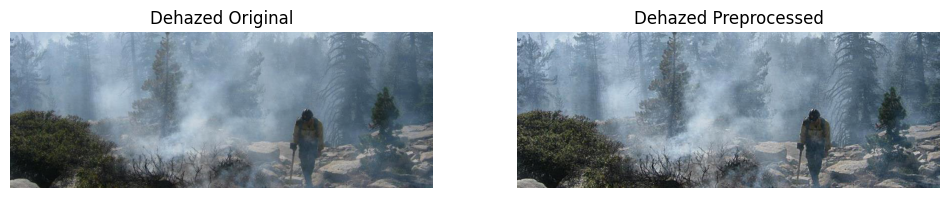

In [18]:
import torch
import torchvision.transforms as transforms
import numpy as np
from PIL import Image
import pyiqa
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

nima_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

from models import dehazeformer_s

model = dehazeformer_s().to(device)
ckpt_path = '/content/drive/MyDrive/DehazeFormer/saved_models/outdoor/dehazeformer-s.pth'
state_dict = torch.load(ckpt_path, map_location=device)
new_state_dict = {k.replace('module.', ''): v for k, v in state_dict['state_dict'].items()}
model.load_state_dict(new_state_dict)
model.eval()
print("DehazeFormer model loaded.")

niqe_metric = pyiqa.create_metric('niqe', device=device)
brisque_metric = pyiqa.create_metric('brisque', device=device)
nima_metric = pyiqa.create_metric('nima-vgg16-ava', device=device)
print("Quality metrics loaded.")

def run_dehazeformer(img_np):
    img = Image.fromarray(img_np).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_tensor).clamp_(-1, 1)
        output = (output * 0.5 + 0.5).squeeze().cpu().numpy()
    output_img = (np.transpose(output, (1, 2, 0)) * 255).astype(np.uint8)
    return output_img

def compute_metrics(img_np):
    img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).float() / 255.0
    pil_img = Image.fromarray(img_np)
    nima_img = nima_transform(pil_img).unsqueeze(0).to(device)
    return {
        'NIQE': niqe_metric(img_tensor.to(device)).item(),
        'BRISQUE': brisque_metric(img_tensor.to(device)).item(),
        'NIMA': nima_metric(nima_img).item()
    }

dehazed_orig = run_dehazeformer(image_rgb)
dehazed_pre = run_dehazeformer(result)
print("Dehazing done.")

orig_metrics = compute_metrics(dehazed_orig)
pre_metrics = compute_metrics(dehazed_pre)

print("\nQuality Metrics:")
print(f"{'Image':<25} | {'Orig→Dehaze':<55} | {'Preproc→Dehaze':<55}")
print("-" * 140)
print(f"{'Inputs':<25} | "
      f"NIQE: {orig_metrics['NIQE']:.2f}, "
      f"BRISQUE: {orig_metrics['BRISQUE']:.2f}, NIMA: {orig_metrics['NIMA']:.2f} | "
      f"NIQE: {pre_metrics['NIQE']:.2f}, "
      f"BRISQUE: {pre_metrics['BRISQUE']:.2f}, NIMA: {pre_metrics['NIMA']:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(dehazed_orig)
axes[0].set_title('Dehazed Original')
axes[0].axis('off')

axes[1].imshow(dehazed_pre)
axes[1].set_title('Dehazed Preprocessed')
axes[1].axis('off')

plt.show()


In [9]:
import os
print(os.getcwd())
print(os.listdir())


/content/DehazeFormer
['configs', 'test.py', 'run.sh', 'datasets', 'utils', 'figs', 'README.md', 'data', 'saved_models', 'train.py', 'processed_YSM_Google_665.png', 'LICENSE', '.gitignore', '.git', 'models', 'YSM_Google_665.png', 'requirements.txt']
